##  **A. Enfoque de validación** 

In [1]:
import pandas as pd
respondieron=pd.read_excel("C:/Users/usuario/Documents/Ciencia-de-Datos/TP3/respondieron_este.xlsx")
print(respondieron.head())
#hice pip install sklearn en la terminal para que ande sklearn
print(respondieron.columns)

   ano4  ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac         ipcf  \
0  2005     1     4     5   1.0         7     4.0         5   280.000000   
1  2005     2     1     5  12.0         7     4.0         5   400.000000   
2  2005     2    78     4   1.0         6     3.0         1  3200.000000   
3  2005     1    16     5   1.0         3     3.0         3   435.000000   
4  2005     1    -1     5   1.0         7     4.0         5   517.333333   

   ch10  ...  pp02e  pp02i  ch09    codusu   sexo  nivel ed adulto_equiv  \
0   1.0  ...    NaN    NaN     2  125082    Varón       NaN         0.55   
1   NaN  ...    NaN    NaN     3  125409    Mujer       NaN         0.37   
2   2.0  ...    NaN    2.0     1  126610    Mujer       NaN         0.63   
3   1.0  ...    NaN    2.0     1  126653    Varón       NaN         1.03   
4   NaN  ...    NaN    NaN     3  126852    Varón       NaN         0.35   

  ad_equiv_hogar  ingreso_necesario  pobre  
0           0.55           112.7885      

In [2]:
norespondieron=pd.read_excel("C:/Users/usuario/Documents/Ciencia-de-Datos/TP3/norespondieron.xlsx")
#para el norespondieron agarré el archivo exportado del tp1 directamente

In [3]:
#chequando los valores
print(respondieron["pobre"].unique())
pobre_percentages = respondieron['pobre'].value_counts(normalize=True) * 100

# Print the resulting Series
print(pobre_percentages)


[0 1]
pobre
1    70.566559
0    29.433441
Name: proportion, dtype: float64


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.api as sm


In [5]:
# Separar por año
df_2005 = respondieron[respondieron["ano4"] == 2005]
df_2025 = respondieron[respondieron["ano4"] == 2025]

In [6]:
X_2005 = df_2005.drop(columns=["pobre", "ano4","ipcf"])
y_2005 = df_2005["pobre"]

X_2025 = df_2025.drop(columns=["pobre", "ano4","ipcf"])
y_2025 = df_2025["pobre"]


In [7]:
# 2005
X_train_2005, X_test_2005, y_train_2005, y_test_2005 = train_test_split(
    X_2005, y_2005, test_size=0.3, random_state=444
)

# 2025
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X_2025, y_2025, test_size=0.3, random_state=444
)

In [8]:
X_train_2005 = sm.add_constant(X_train_2005)
X_test_2005 = sm.add_constant(X_test_2005)

X_train_2025 = sm.add_constant(X_train_2025)
X_test_2025 = sm.add_constant(X_test_2025)

**Ejercicio 1**

In [9]:
# Renombrar columnas según tu diccionario
rename_dict = {
    "ch04": "sexo1",
    "ch06": "edad",
    "ch08": "cobertura_medica",
    "nivel_ed": "nivel_educativo",
    "cat_inac": "categoria_inactividad",
    "ch10": "asistir_educacion",
    "pp02i": "trabajo_ult_12_meses",
    "ad_equiv_hogar": "ad_equiv_hogar"
}

X_train_2005 = X_train_2005.rename(columns=rename_dict)
X_test_2005 = X_test_2005.rename(columns=rename_dict)

In [10]:
vars_X = list(rename_dict.values())  # nombres ya renombrados
X_train_sel = X_train_2005[vars_X]
X_test_sel = X_test_2005[vars_X]

In [11]:
from scipy import stats
import pandas as pd

diff_table = pd.DataFrame(columns=["mean_train", "mean_test", "diff", "p_value"])

for var in vars_X:
    mean_train = X_train_sel[var].mean()
    mean_test = X_test_sel[var].mean()
    diff = mean_train - mean_test
    t_stat, p_val = stats.ttest_ind(
        X_train_sel[var], X_test_sel[var],
        equal_var=False, nan_policy='omit'
    )
    diff_table.loc[var] = [mean_train, mean_test, diff, p_val]

diff_table = diff_table.round(3)
print(diff_table)

                       mean_train  mean_test   diff  p_value
sexo1                       1.599      1.595  0.003    0.775
edad                       29.178     29.433 -0.255    0.696
cobertura_medica            2.861      2.730  0.131    0.242
nivel_educativo             3.265      3.290 -0.025    0.636
categoria_inactividad       3.305      3.323 -0.018    0.624
asistir_educacion           1.557      1.564 -0.008    0.631
trabajo_ult_12_meses        1.978      1.972  0.005    0.232
ad_equiv_hogar              2.187      2.170  0.017    0.586


In [12]:
diff_table.to_excel("diferencias_train_test_2005.xlsx", index=True)

**Ejercicio 2**

In [12]:
respondieron_2005 = respondieron[respondieron["ano4"] == 2005].copy()
respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

norespondieron_2005 = norespondieron[norespondieron["ano4"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

# Mostrar la cantidad de filas para verificar
print("Respondieron 2005:", respondieron_2005.shape)
print("Respondieron 2025:", respondieron_2025.shape)
print("No respondieron 2005:", norespondieron_2005.shape)
print("No respondieron 2025:", norespondieron_2025.shape)

Respondieron 2005: (8028, 23)
Respondieron 2025: (9340, 23)
No respondieron 2005: (107, 19)
No respondieron 2025: (4461, 19)


## **B. Modelo de Regresion Logistica**

**Ejercicio 3**

In [13]:
import pandas as pd
import numpy as np

# Hacemos una copia para trabajar
df_train = X_train_2005.copy()

# ======================
# SEXO1: 1 = varón, 2 = mujer → 0 = varón, 1 = mujer
# ======================
df_train["sexo1"] = df_train["sexo1"].replace({1: 0, 2: 1})

# ======================
# COBERTURA_MEDICA:
# 1,2,3,12,13,23,123 → tiene cobertura (0)
# 4 → no tiene cobertura (1)
# 9 → NA
# ======================
df_train["cobertura_medica"] = np.where(df_train["cobertura_medica"] == 4, 1,
                                np.where(df_train["cobertura_medica"].isin([1,2,3,12,13,23,123]), 0, np.nan))

# ======================
# CAT_INAC:
# 1=Jubilado/pensionado 2=Rentista 3=Estudiante 4=Ama de casa
# 5=Menor 6=Discapacitado 7=Otros
# Creamos dummies (dejamos "Otros" como base)
# ======================
catinac_dummies = pd.get_dummies(df_train["categoria_inactividad"],
                                 prefix="inac", drop_first=False)
catinac_dummies.columns = [
    "inac_jubilado", "inac_rentista", "inac_estudiante",
    "inac_ama_casa", "inac_menor", "inac_discapacitado", "inac_otros"
]
# Base: "inac_otros"
catinac_dummies = catinac_dummies.drop(columns="inac_otros")

# ======================
# TRABAJO_ULT_12_MESES: 1=Sí, 2=No → 1=trabajó, 0=no trabajó
# ======================
df_train["trabajo_ult_12_meses"] = df_train["trabajo_ult_12_meses"].replace({1:1, 2:0})

In [14]:
# Unimos las dummies creadas
df_train_dummies = pd.concat(
    [df_train.drop(columns=["categoria_inactividad"]), catinac_dummies],
    axis=1
)

# Confirmar columnas finales
print("Columnas finales para el modelo:")
print(df_train_dummies.columns.tolist())


Columnas finales para el modelo:
['const', 'sexo1', 'edad', 'ch07', 'cobertura_medica', 'nivel_educativo', 'estado', 'asistir_educacion', 'ch03', 'ch14', 'ch15', 'pp02e', 'trabajo_ult_12_meses', 'ch09', 'codusu', 'sexo', 'nivel ed', 'adulto_equiv', 'ad_equiv_hogar', 'ingreso_necesario', 'inac_jubilado', 'inac_rentista', 'inac_estudiante', 'inac_ama_casa', 'inac_menor', 'inac_discapacitado']


In [17]:
import statsmodels.api as sm

# Variable dependiente
y_train = y_train_2005

# Agregar constante
X_logit = df_train_dummies[['const', 'sexo1', 'edad', 'nivel_educativo',  'trabajo_ult_12_meses', 'ad_equiv_hogar',
                            'inac_jubilado', 'inac_rentista', 'inac_estudiante', 'inac_ama_casa', 'inac_discapacitado']]
X_logit = X_logit.astype(float)  # también podrías usar .astype(int)

# Ajustar modelo Logit
logit_model = sm.Logit(y_train, X_logit, missing='drop')
result = logit_model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.384539
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  pobre   No. Observations:                 4063
Model:                          Logit   Df Residuals:                     4052
Method:                           MLE   Df Model:                           10
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                  0.4216
Time:                        15:15:20   Log-Likelihood:                -1562.4
converged:                       True   LL-Null:                       -2701.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.4681      0.338     -4.338      0.000      -2.132      -0.805

In [18]:
# Extraer coeficientes y errores estándar
coef = result.params
std_err = result.bse
odds_ratio = np.exp(coef)

tabla_logit = pd.DataFrame({
    "Coeficiente": coef.round(4),
    "Error Std.": std_err.round(4),
    "Odds Ratio": odds_ratio.round(4)
})

# Exportar a Excel
tabla_logit.to_excel("logit_resultados_2005.xlsx", index=True)
print("✅ Resultados guardados en 'logit_resultados_2005.xlsx'")

✅ Resultados guardados en 'logit_resultados_2005.xlsx'


### Ejercicio 4: Visualización

In [19]:
from sklearn.model_selection import train_test_split

YEAR_COL = "ano4"
years = sorted(respondieron[YEAR_COL].dropna().unique())
splits = {}
for year in years:
    # Filtrar cada año
    dfy = respondieron[respondieron[YEAR_COL] == year].copy()

    # Variable dependiente
    y = dfy["pobre"].copy()

    # Variables independientes (sin 'pobre', 'ingreso' ni 'ipcf')
    X = dfy.drop(columns=["pobre", "ingreso", "ipcf"], errors="ignore")

    # División 70/30 con semilla 444
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=y
    )

    # 💡 AGREGAR AQUÍ la columna de unos (intercepto)
    Xtr = Xtr.assign(intercepto=1)
    Xte = Xte.assign(intercepto=1)

    # Guardar los splits por año
    splits[year] = {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}

C:\Users\usuario\AppData\Local\Temp\ipykernel_8356\1435186470.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


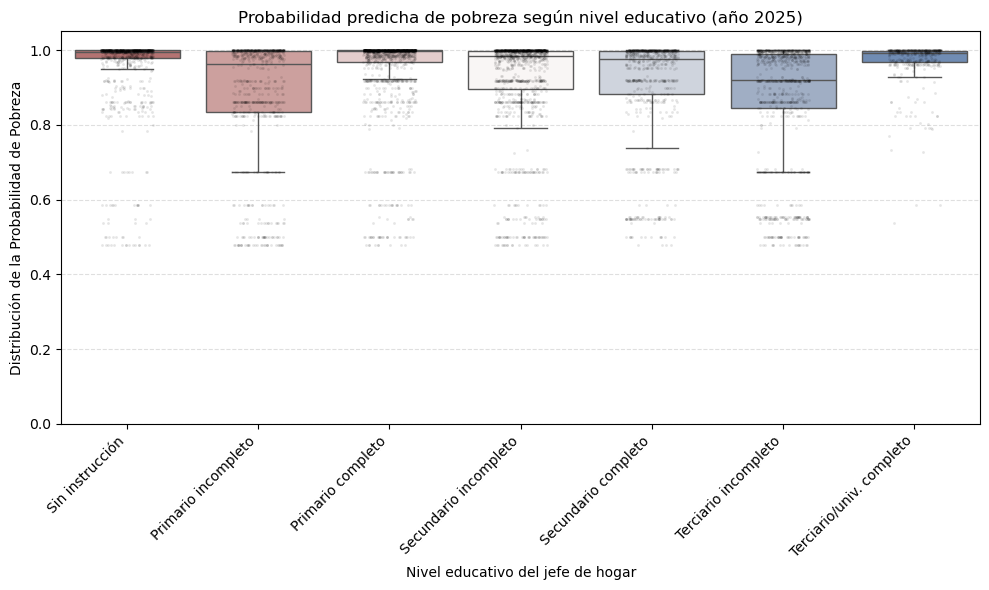

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm  # <- para add_constant

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# === preparar X_train con las MISMAS dummies que usó el Logit ===
X_train_raw = splits[año]["X_train"].copy()

# quitar ingresos/intercepto por las dudas
#cols_drop = [c for c in X_train_raw.columns
 #            if c.lower() in ["ipcf", "ingreso", "itf", "intercepto"] or "ingreso" in c.lower()]
#X_base = X_train_raw.drop(columns=cols_drop, errors="ignore")

# imputación mínima antes de dummies
X_num = X_train_raw.select_dtypes(include=np.number).copy().fillna(X_train_raw.select_dtypes(include=np.number).median())
X_cat = X_train_raw.select_dtypes(exclude=np.number).copy()
if not X_cat.empty:
    X_cat = X_cat.fillna(X_cat.mode().iloc[0])

# dummies (drop_first=True como en entrenamiento)
X_dum = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)

# alinear columnas a las del modelo (res)
cols_model = [c for c in result.params.index if c.lower() not in ["const","intercept","intercepto"]]
X_aligned = X_dum.reindex(columns=cols_model, fill_value=0)
X_aligned = sm.add_constant(X_aligned, has_constant='add')

# probabilidad predicha
prob_pred = result.predict(X_aligned)

# DataFrame para graficar
df_plot = pd.DataFrame({
    variable: X_train_raw[variable],
    'Prob_Pobre': prob_pred
}).dropna(subset=[variable])

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}

# columnas categóricas para el eje X
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)
category_order = list(etiquetas_nivel.values())

# --- Gráfico ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    palette='vlag_r',
    showfliers=False
)
sns.stripplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    color='black',
    alpha=0.1,
    jitter=0.2,
    s=2
)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza")
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
print(prob_pred.describe())
print(y_train.value_counts(normalize=True))

count    6538.000000
mean        0.919376
std         0.136565
min         0.478165
25%         0.906234
50%         0.984532
75%         0.998267
max         1.000000
dtype: float64
pobre
1    0.641395
0    0.358605
Name: proportion, dtype: float64


C:\Users\usuario\AppData\Local\Temp\ipykernel_8356\3959354396.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


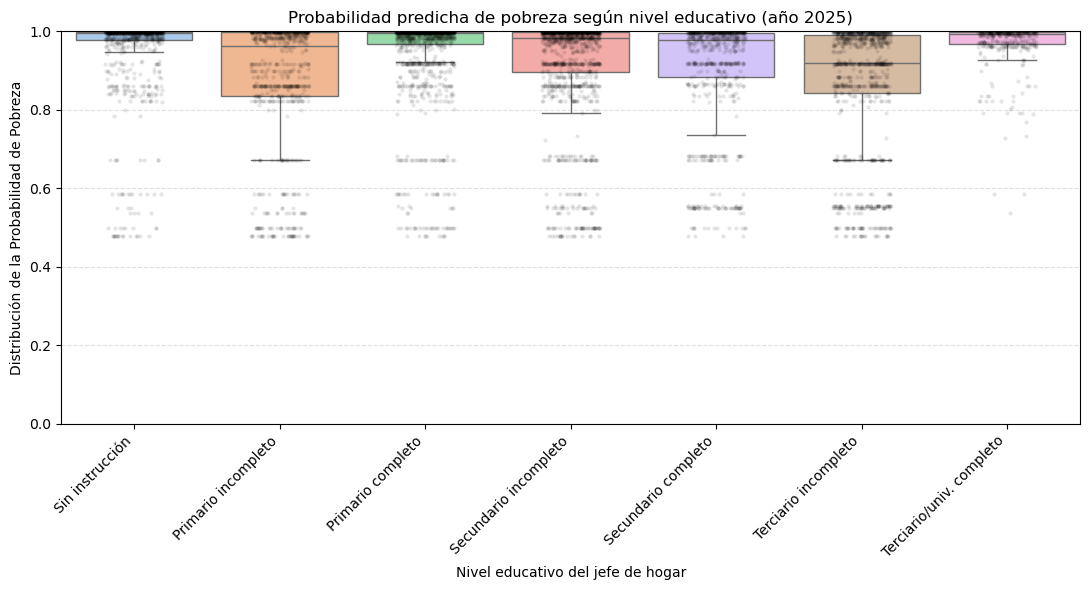

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# === preparar X_train con las MISMAS dummies que usó el Logit ===
X_train_raw = splits[año]["X_train"].copy()

cols_drop = [c for c in X_train_raw.columns
             if c.lower() in ["ipcf", "ingreso", "itf", "intercepto"] or "ingreso" in c.lower()]
X_base = X_train_raw.drop(columns=cols_drop, errors="ignore")

X_num = X_base.select_dtypes(include=np.number).copy().fillna(X_base.select_dtypes(include=np.number).median())
X_cat = X_base.select_dtypes(exclude=np.number).copy()
if not X_cat.empty:
    X_cat = X_cat.fillna(X_cat.mode().iloc[0])

X_dum = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)

cols_model = [c for c in result.params.index if c.lower() not in ["const","intercept","intercepto"]]
X_aligned = X_dum.reindex(columns=cols_model, fill_value=0)
X_aligned = sm.add_constant(X_aligned, has_constant='add')

prob_pred = result.predict(X_aligned)

# DataFrame para graficar
df_plot = pd.DataFrame({
    variable: X_train_raw[variable],
    'Prob_Pobre': prob_pred
}).dropna(subset=[variable])

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)
category_order = list(etiquetas_nivel.values())

# --- Gráfico ---
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    showfliers=False,
    palette='pastel'
)
sns.stripplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    alpha=0.1,
    s=3,
    jitter=0.2,
    color='black'
)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza")
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


C:\Users\usuario\AppData\Local\Temp\ipykernel_8356\3302105980.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_plot_age, x='Edad', y='Prob_Pobre', alpha=0.7, palette="coolwarm", s=70, edgecolor='w')


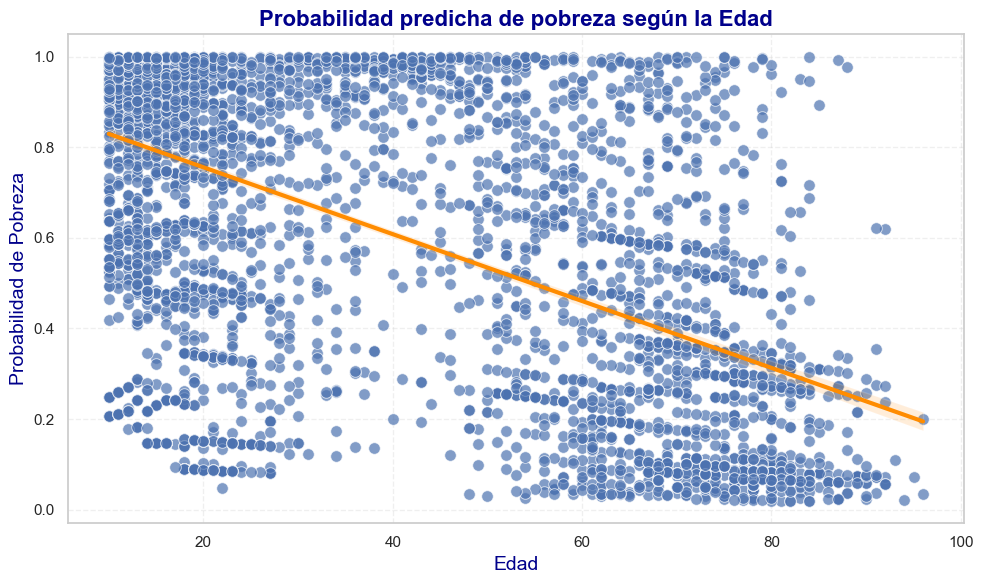

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un nuevo DataFrame con las predicciones para la variable 'edad'
df_plot_age = pd.DataFrame({
    'Edad': X_train_2005['edad'],          # Variable de edad
    'Prob_Pobre': result.predict(X_logit)  # Probabilidad predicha de pobreza
})

# Establecer un estilo bonito con Seaborn
sns.set(style="whitegrid")

# Graficar
plt.figure(figsize=(10, 6))

# Puntos con color atractivo
sns.scatterplot(data=df_plot_age, x='Edad', y='Prob_Pobre', alpha=0.7, palette="coolwarm", s=70, edgecolor='w')

# Ajustar línea de tendencia
sns.regplot(data=df_plot_age, x='Edad', y='Prob_Pobre', scatter=False, color='darkorange', line_kws={'linewidth': 3})

# Etiquetas y título con un toque profesional
plt.title('Probabilidad predicha de pobreza según la Edad', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Edad', fontsize=14, color='darkblue')
plt.ylabel('Probabilidad de Pobreza', fontsize=14, color='darkblue')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Mostrar gráfico
plt.show()

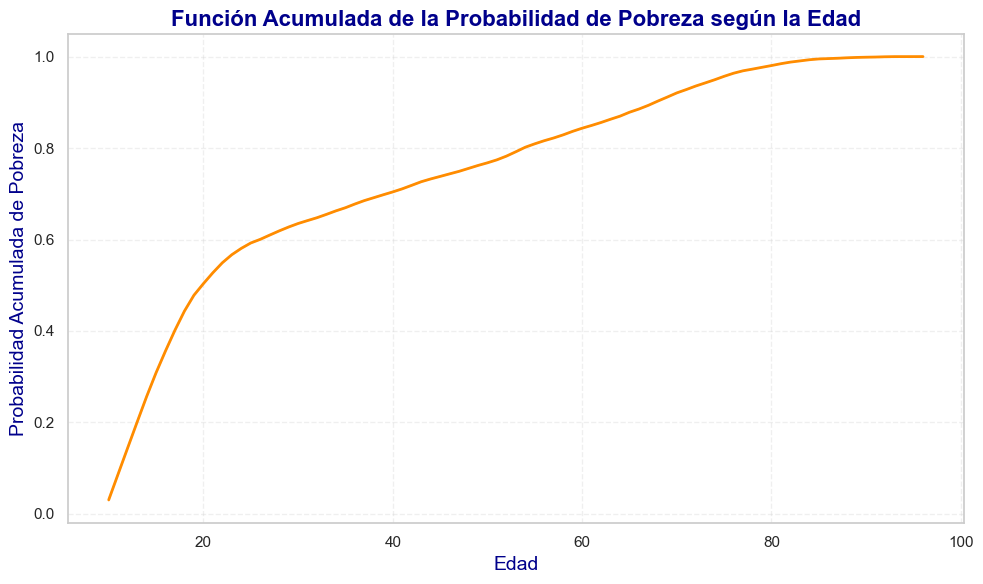

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un nuevo DataFrame con las predicciones para la variable 'edad'
df_plot_age = pd.DataFrame({
    'Edad': X_train_2005['edad'],          # Variable de edad
    'Prob_Pobre': result.predict(X_logit)  # Probabilidad predicha de pobreza
})

# Ordenar por edad para graficar la curva acumulada
df_plot_age = df_plot_age.sort_values('Edad')

# Calcular la función acumulada de la probabilidad de pobreza
df_plot_age['Cumulative_Prob'] = df_plot_age['Prob_Pobre'].cumsum() / df_plot_age['Prob_Pobre'].sum()

# Establecer un estilo bonito con Seaborn
sns.set(style="whitegrid")

# Graficar
plt.figure(figsize=(10, 6))

# Graficar la función acumulada
sns.lineplot(data=df_plot_age, x='Edad', y='Cumulative_Prob', color='darkorange', linewidth=2)

# Etiquetas y título con un toque profesional
plt.title('Función Acumulada de la Probabilidad de Pobreza según la Edad', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Edad', fontsize=14, color='darkblue')
plt.ylabel('Probabilidad Acumulada de Pobreza', fontsize=14, color='darkblue')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Mostrar gráfico
plt.show()

## **C. Método de Vecinos Cercanos (KNN)**

### 5. Estimación

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

año = 2025
Xtr = splits[año]["X_train"].drop(columns=["intercepto"], errors="ignore").copy()
ytr = splits[año]["y_train"].copy()
Xte = splits[año]["X_test"].drop(columns=["intercepto"], errors="ignore").copy()
yte = splits[año]["y_test"].copy()

# --- 1) Reclasificar columnas object: numéricas "disfrazadas" vs texto real ---
obj_cols = Xtr.select_dtypes(include="object").columns.tolist()

num_like, cat_cols = [], []
for c in obj_cols:
    s = pd.to_numeric(pd.concat([Xtr[c], Xte[c]], axis=0), errors="coerce")
    # si al menos 90% se puede convertir a número, la tratamos como numérica
    if s.notna().mean() >= 0.9:
        # convertir en ambos sets
        Xtr[c] = pd.to_numeric(Xtr[c], errors="coerce")
        Xte[c] = pd.to_numeric(Xte[c], errors="coerce")
        num_like.append(c)
    else:
        cat_cols.append(c)

num_cols = Xtr.select_dtypes(include=[np.number]).columns.tolist()
# asegurar que no quede ninguna numérica en cat
cat_cols = [c for c in cat_cols if c not in num_cols]

# Opcional: descartar posibles IDs de cardinalidad altísima (evita matrices gigantes)
high_card = [c for c in cat_cols if Xtr[c].nunique() > 0.5 * len(Xtr)]
cat_cols = [c for c in cat_cols if c not in high_card]

# --- 2) Preprocesamiento ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# --- 3) KNN con K = 1, 5, 10 ---
resultados = []
for k in [1, 5, 10]:
    clf = Pipeline(steps=[("prep", preprocess),
                         ("knn", KNeighborsClassifier(n_neighbors=k))])
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    resultados.append({"K": k, "Accuracy_test": accuracy_score(yte, yhat)})

pd.DataFrame(resultados)


C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
 

,K,Accuracy_test
0,1,0.846538
1,5,0.875803
2,10,0.871877


### 6. Visualización

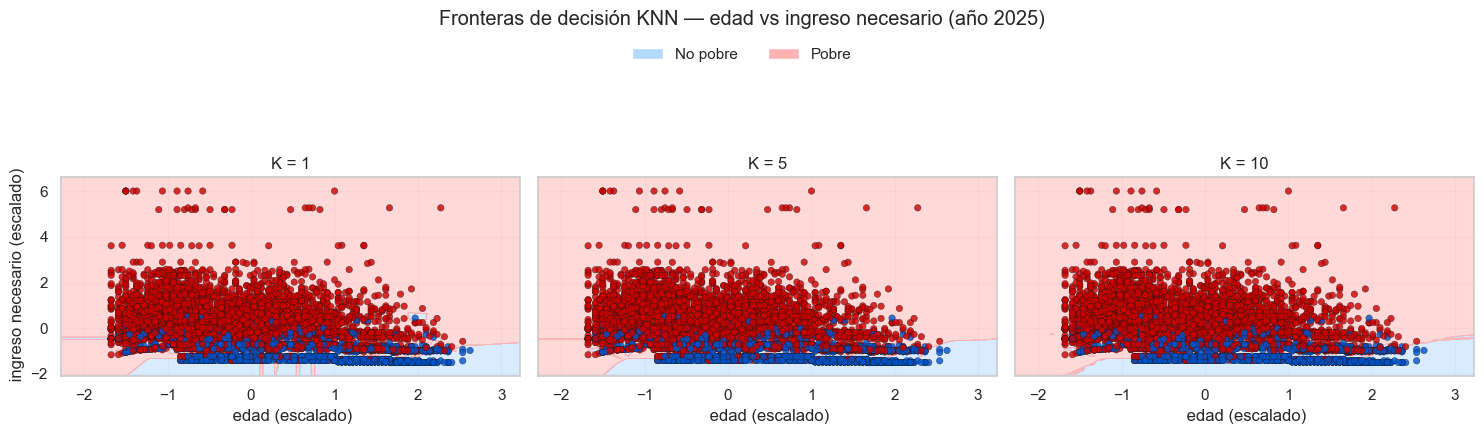

In [33]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd 
vars_plot = ["ch06", "ingreso_necesario"] 

df = splits[año]["X_train"][vars_plot].dropna().copy()
y  = splits[año]["y_train"].loc[df.index].values

scaler = StandardScaler()
Xz = scaler.fit_transform(df.values)

pad=0.6
xx, yy = np.meshgrid(
    np.linspace(Xz[:,0].min()-pad, Xz[:,0].max()+pad, 400),
    np.linspace(Xz[:,1].min()-pad, Xz[:,1].max()+pad, 400)
)

cmap_bg  = ListedColormap(["#b3d9ff","#ffb3b3"])
cmap_pts = ListedColormap(["#0052cc","#cc0000"])

fig, axes = plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax, k in zip(axes,[1,5,10]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xz, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    # Nota: Aquí no se usa jitter, se usa Xz directamente, como en tu código original
    ax.scatter(Xz[:,0], Xz[:,1], c=y, cmap=cmap_pts, s=22, edgecolor="k", lw=0.3, alpha=0.8) 
    ax.set_title(f"K = {k}"); ax.grid(alpha=.2)
    ax.set_xlabel(f" edad (escalado)")
axes[0].set_ylabel(f" ingreso necesario (escalado)")

# --- AJUSTES PARA EVITAR SOLAPAMIENTO ---

# 1. Título principal: Se posiciona más alto (y=1.08)
fig.suptitle(f"Fronteras de decisión KNN — edad vs ingreso necesario (año {año})", y=1.08)

# 2. Leyenda: Se coloca debajo del suptitle (y=1.02)
fig.legend([Patch(facecolor="#b3d9ff"), Patch(facecolor="#ffb3b3")],
           ["No pobre","Pobre"], 
           loc="upper center", 
           bbox_to_anchor=(0.5, 1.02), # El ajuste clave para la posición de la leyenda
           ncol=2, 
           frameon=False)

# 3. tight_layout: Se reduce el área de los subplots para dejar espacio superior (rect=[0, 0, 1, 0.85])
plt.tight_layout(rect=[0, 0, 1, 0.85]) 

plt.show()

### Ejercicio 7

In [34]:
# === IMPORTS NECESARIOS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# === 1) Datos: respondieron_2025 ===
# (si no está en memoria, filtralo antes)
# respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

y = respondieron_2025["pobre"].astype(int).copy()
X = respondieron_2025.drop(columns=["pobre", "ingreso", "ipcf", "intercepto"], errors="ignore").copy()

# === 2) Identificar tipos de variables ===
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# eliminar categóricas con cardinalidad excesiva (IDs, códigos únicos, etc.)
high_card = [c for c in cat_cols if X[c].nunique() > 0.5 * len(X)]
cat_cols = [c for c in cat_cols if c not in high_card]

# === 3) Preprocesamiento ===
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

# === 4) Búsqueda de K por 5-fold CV ===
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 20, 25]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

cv_stats = []
for k in k_values:
    pipe = Pipeline([
        ("prep", pre),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    cv_stats.append({
        "K": k,
        "Accuracy_mean": scores.mean(),
        "Accuracy_std": scores.std()
    })

# mostrar tabla completa sin recorte
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

display(cv_df)


# === 5) Gráfico Accuracy vs K ===
plt.figure(figsize=(7, 4))
plt.plot(cv_df["K"], cv_df["Accuracy_mean"], marker="o", color="#0072B2")
plt.fill_between(
    cv_df["K"],
    cv_df["Accuracy_mean"] - cv_df["Accuracy_std"],
    cv_df["Accuracy_mean"] + cv_df["Accuracy_std"],
    color="#0072B2", alpha=0.2
)
plt.xlabel("K")
plt.ylabel("Accuracy (5-fold CV)")
plt.title("Selección de K por Cross-Validation (respondieron 2025)")
plt.grid(True, alpha=0.3)
plt.show()

# === 6) K óptimo ===
k_opt = int(cv_df.loc[cv_df["Accuracy_mean"].idxmax(), "K"])
print(f"K óptimo por 5-fold CV: {k_opt}")

# === 7) Entrenar modelo final ===
knn_cv = Pipeline([
    ("prep", pre),
    ("knn", KNeighborsClassifier(n_neighbors=k_opt))
])
knn_cv.fit(X, y)

C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
 

NameError: name 'cv_df' is not defined

C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
 

,K,Accuracy_mean,Accuracy_std
0,1,0.845182,0.004852
1,3,0.864561,0.009888
2,5,0.873126,0.009678
3,7,0.877623,0.007828
4,9,0.878373,0.008453
5,11,0.876981,0.006792
6,13,0.878373,0.006089
7,15,0.877302,0.007296
8,20,0.878373,0.004946
9,25,0.880728,0.005547


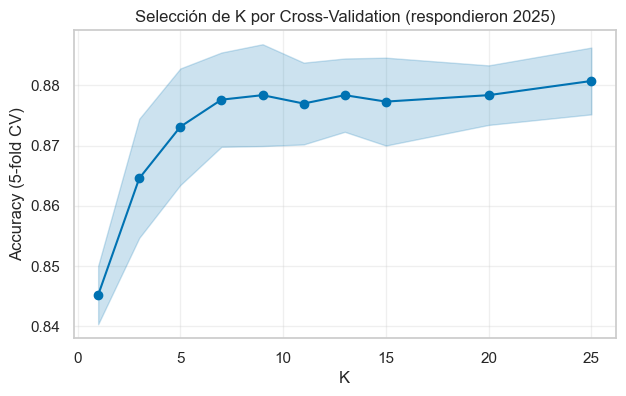

K óptimo por 5-fold CV: 25


C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['ano4', 'ch04', 'ch06',
                                                   'ch07', 'ch08', 'nivel_ed',
                                                   'estado', 'cat_inac', 'ch10',
                                                   'ch03', 'ch14', 'ch15',
                                                   'pp02e', 'pp02i', 'ch09',
                                                   'nivel ed', 'adulto_equiv',
                                                   'ad_equiv_hogar',
                                                   'ingreso_necesario']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['codusu', 'sexo'])])),
                ('knn', KNeighborsClassifier(n_neighbors=25))])

In [35]:
# === IMPORTS NECESARIOS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# === 1) Datos: respondieron_2025 ===
# (si no está en memoria, filtralo antes)
# respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

y = respondieron_2025["pobre"].astype(int).copy()
X = respondieron_2025.drop(columns=["pobre", "ingreso", "ipcf", "intercepto"], errors="ignore").copy()

# === 2) Identificar tipos de variables ===
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# eliminar categóricas con cardinalidad excesiva (IDs, códigos únicos, etc.)
high_card = [c for c in cat_cols if X[c].nunique() > 0.5 * len(X)]
cat_cols = [c for c in cat_cols if c not in high_card]

# === 3) Preprocesamiento ===
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

# === 4) Búsqueda de K por 5-fold CV ===
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 20, 25]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

cv_stats = []
for k in k_values:
    pipe = Pipeline([
        ("prep", pre),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    cv_stats.append({
        "K": k,
        "Accuracy_mean": scores.mean(),
        "Accuracy_std": scores.std()
    })

# mostrar tabla completa sin recorte
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# === 4.5) Convertir resultados a DataFrame ===
cv_df = pd.DataFrame(cv_stats)

display(cv_df)


# === 5) Gráfico Accuracy vs K ===
plt.figure(figsize=(7, 4))
plt.plot(cv_df["K"], cv_df["Accuracy_mean"], marker="o", color="#0072B2")
plt.fill_between(
    cv_df["K"],
    cv_df["Accuracy_mean"] - cv_df["Accuracy_std"],
    cv_df["Accuracy_mean"] + cv_df["Accuracy_std"],
    color="#0072B2", alpha=0.2
)
plt.xlabel("K")
plt.ylabel("Accuracy (5-fold CV)")
plt.title("Selección de K por Cross-Validation (respondieron 2025)")
plt.grid(True, alpha=0.3)
plt.show()

# === 6) K óptimo ===
k_opt = int(cv_df.loc[cv_df["Accuracy_mean"].idxmax(), "K"])
print(f"K óptimo por 5-fold CV: {k_opt}")

# === 7) Entrenar modelo final ===
knn_cv = Pipeline([
    ("prep", pre),
    ("knn", KNeighborsClassifier(n_neighbors=k_opt))
])
knn_cv.fit(X, y)

## **D. Desempeño de modelos, elección y predicción afuera de la muestra**

### Ejercicio 8

C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


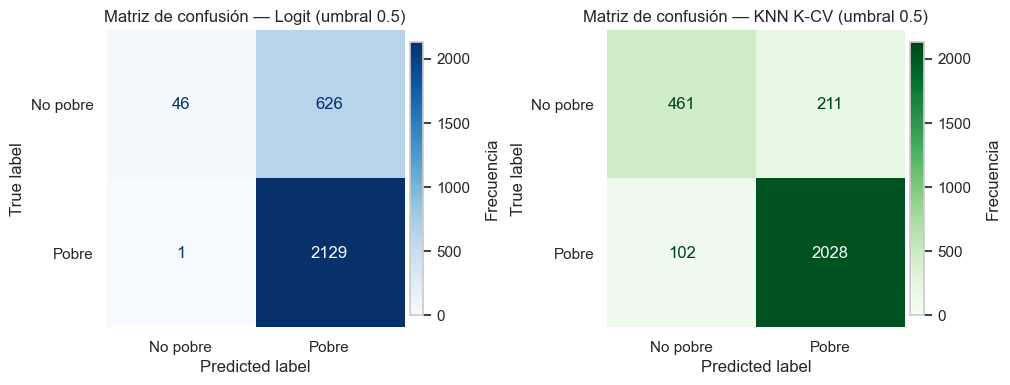

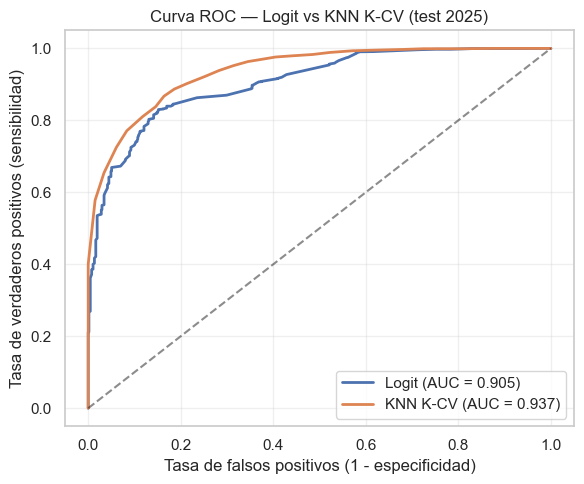

Métricas en test (umbral 0.5)


,Modelo,Accuracy,Precision,Recall,AUC
0,Logit,0.7762,0.7728,0.9995,0.9054
1,KNN K-CV,0.8883,0.9058,0.9521,0.9370


In [41]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# ---------- helper para armar dummies igual que en el entrenamiento ----------
def build_X_with_dummies(df, drop_income_cols=True, ref_cols=None):
    X = df.copy()
    if drop_income_cols:
        forbid = {"pobre","ipcf","itf","intercepto"}
        extra = [c for c in X.columns if "ingreso" in c.lower()]
        X = X.drop(columns=list(forbid)+extra, errors="ignore")

    num = X.select_dtypes(include=np.number).copy()
    cat = X.select_dtypes(exclude=np.number).copy()
    if not num.empty: num = num.fillna(num.median())
    if not cat.empty: cat = cat.fillna(cat.mode().iloc[0])

    Xd = pd.get_dummies(pd.concat([num, cat], axis=1), drop_first=True)
    if ref_cols is not None:
        Xd = Xd.reindex(columns=ref_cols, fill_value=0)
    Xd = sm.add_constant(Xd, has_constant='add')  # agrega 'const'
    return Xd

# ========== 1) Datos de test ==========
X_test_raw = splits[2025]["X_test"].copy()
y_test     = splits[2025]["y_test"].astype(int).copy()

# columnas que usó el logit (sin la constante)
cols_model_x = [c for c in result.params.index if c.lower() not in ["const","intercept","intercepto"]]

# ========== 2) LOGIT: probs y clases (umbral 0.5) ==========
X_test_logit = build_X_with_dummies(X_test_raw, drop_income_cols=True, ref_cols=cols_model_x)
prob_logit   = result.predict(X_test_logit)
pred_logit   = (prob_logit > 0.5).astype(int)

# ========== 3) KNN con K-CV: probs y clases (umbral 0.5) ==========
# (knn_cv es tu pipeline ya entrenado en el inciso 7)
prob_knn = knn_cv.predict_proba(X_test_raw)[:, 1]
pred_knn = (prob_knn > 0.5).astype(int)

# ========== 4) MATRICES DE CONFUSIÓN ==========
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Confusion matrices (mismo rango de color)
cm_logit = confusion_matrix(y_test, pred_logit)
cm_knn   = confusion_matrix(y_test, pred_knn)
vmin, vmax = 0, max(cm_logit.max(), cm_knn.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# --- LOGIT ---
disp1 = ConfusionMatrixDisplay(cm_logit, display_labels=["No pobre", "Pobre"])
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format='d')
axes[0].set_title("Matriz de confusión — Logit (umbral 0.5)")
axes[0].grid(False)
for sp in axes[0].spines.values(): sp.set_visible(False)
disp1.im_.set_clim(vmin=vmin, vmax=vmax)
# Barra azul
cbar1 = fig.colorbar(disp1.im_, ax=axes[0], fraction=0.046, pad=0.02)
cbar1.set_label("Frecuencia", rotation=90, labelpad=10)

# --- KNN ---
disp2 = ConfusionMatrixDisplay(cm_knn, display_labels=["No pobre", "Pobre"])
disp2.plot(ax=axes[1], cmap="Greens", colorbar=False, values_format='d')
axes[1].set_title("Matriz de confusión — KNN K-CV (umbral 0.5)")
axes[1].grid(False)
for sp in axes[1].spines.values(): sp.set_visible(False)
disp2.im_.set_clim(vmin=vmin, vmax=vmax)
# Barra verde
cbar2 = fig.colorbar(disp2.im_, ax=axes[1], fraction=0.046, pad=0.02)
cbar2.set_label("Frecuencia", rotation=90, labelpad=10)

plt.show()

# ========== 5) CURVAS ROC ==========
fpr_logit, tpr_logit, _ = roc_curve(y_test, prob_logit)
fpr_knn,   tpr_knn,   _ = roc_curve(y_test, prob_knn)
auc_logit = roc_auc_score(y_test, prob_logit)
auc_knn   = roc_auc_score(y_test, prob_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})", lw=2)
plt.plot(fpr_knn,   tpr_knn,   label=f"KNN K-CV (AUC = {auc_knn:.3f})", lw=2)
plt.plot([0,1],[0,1],"k--",alpha=0.5)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC — Logit vs KNN K-CV (test 2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ========== 6) MÉTRICAS (umbral 0.5) ==========
def resumen_metricas(y_true, y_pred, y_prob, nombre):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

tabla = pd.DataFrame([
    resumen_metricas(y_test, pred_logit, prob_logit, "Logit"),
    resumen_metricas(y_test, pred_knn,   prob_knn,   "KNN K-CV")
]).round(4)

print("Métricas en test (umbral 0.5)")
display(tabla)

### Ejercicio 9

No hay que hacer codigo

### Ejercicio 10

In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

# 1) Filtrar 2025 en ambas bases
resp_2025 = respondieron[respondieron["ano4"] == 2025].copy()
noresp_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

# 2) Definir X e y en respondieron (sin ingresos)
drop_cols = ["pobre", "ingreso", "ipcf", "intercepto"]
Xr = resp_2025.drop(columns=drop_cols, errors="ignore").copy()
yr = resp_2025["pobre"].astype(int).copy()

# 3) X en norespondieron (mismo drop)
Xn = noresp_2025.drop(columns=drop_cols, errors="ignore").copy()

# 4) Usar SOLO columnas comunes a ambas bases
common_cols = sorted(list(set(Xr.columns) & set(Xn.columns)))
Xr = Xr[common_cols].copy()
Xn = Xn[common_cols].copy()

# 5) Separar tipos sobre la intersección
num_cols = Xr.select_dtypes(include=np.number).columns.tolist()
cat_cols = Xr.select_dtypes(exclude=np.number).columns.tolist()

# (opcional) filtrar categóricas de cardinalidad muy alta
high_card = [c for c in cat_cols if Xr[c].nunique() > 0.5 * len(Xr)]
cat_cols = [c for c in cat_cols if c not in high_card]

# 6) Preprocesamiento idéntico al usado antes
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 7) Entrenar KNN con el K óptimo que ya tenías (k_opt)
#    Si no tenés k_opt en memoria, podés volver a calcularlo rápidamente.
knn_final = Pipeline([
    ("prep", pre),
    ("knn", KNeighborsClassifier(n_neighbors=int(k_opt)))
])
knn_final.fit(Xr, yr)

# 8) Predecir en norespondieron_2025
pred_n = knn_final.predict(Xn)
noresp_2025["pred_pobre"] = pred_n

# 9) Proporción de no respondientes clasificados como pobres
prop_pobres_pred = noresp_2025["pred_pobre"].mean()
print(f"Proporción de no respondientes clasificados como pobres: {prop_pobres_pred:.3f}")

# 10) (Opcional) tabla de conteos %
conteo = noresp_2025["pred_pobre"].value_counts(normalize=True).mul(100).round(2)
print("\n% por clase predicha en norespondieron 2025:")
print(conteo.rename(index={0: "No pobre", 1: "Pobre"}))

# 11) (Opcional) ver qué columnas se perdieron por no estar en ambas bases
perdidas = sorted(set(resp_2025.columns) - set(common_cols))
print("\nColumnas presentes en respondieron_2025 pero NO en norespondieron_2025 (drop por intersección):")
print(perdidas[:20], "..." if len(perdidas) > 20 else "")

C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\usuario\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Proporción de no respondientes clasificados como pobres: 0.842

% por clase predicha en norespondieron 2025:
pred_pobre
Pobre       84.22
No pobre    15.78
Name: proportion, dtype: float64

Columnas presentes en respondieron_2025 pero NO en norespondieron_2025 (drop por intersección):
['ad_equiv_hogar', 'adulto_equiv', 'ingreso_necesario', 'ipcf', 'pobre'] 
